# Land Pixels — TOA Radiance & Assumed Far-Red SIF

Selects **10 random pixels with NDVI > 0.8** from a PACE OCI granule
(2025-07-02) using the LANDVI V3.1 product, plots their TOA radiance
spectra (650–800 nm) from the matching L1B file, and computes the ratio
of an **assumed SIF of 0.5 W m⁻² sr⁻¹ µm⁻¹** to the local background
continuum radiance.

In [21]:
# ── Cell 1: Configuration ────────────────────────────────────────────────────
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import netCDF4 as nc
import earthaccess

LANDVI_GRANULE = "PACE_OCI.20250702T170504.L2.LANDVI.V3_1.nc"
L1B = "/home/zhe2/data/PACE/L1B_V3/PACE_OCI.20250702T170504.L1B.V3.nc"
GRANULE_TS     = "2025-07-02T17:05:04"

ASSUMED_SIF = 0.5          # W m⁻² sr⁻¹ µm⁻¹  (flat across all wavelengths)
NDVI_MIN    = 0.8          # minimum NDVI threshold for pixel selection
N_PIX       = 10           # number of random pixels to plot
RANDOM_SEED = 42

PLOT_WL  = (650.0, 800.0)  # nm
BG_LEFT  = (650.0, 665.0)  # nm  ─┐ continuum windows flanking 678 nm SIF peak
BG_RIGHT = (695.0, 710.0)  # nm  ─┘

print("Configuration OK")
print(f"NDVI threshold: > {NDVI_MIN}   |   Assumed SIF = {ASSUMED_SIF} W m⁻² sr⁻¹ µm⁻¹")

Configuration OK
NDVI threshold: > 0.8   |   Assumed SIF = 0.5 W m⁻² sr⁻¹ µm⁻¹


In [22]:
# ── Cell 2: Search LANDVI via earthaccess & select pixels with NDVI > 0.8 ────
earthaccess.login(strategy="netrc")
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_LANDVI",
    temporal=("2025-07-02T17:04:00", "2025-07-02T17:06:00"),
    count=5,
)
match = [r for r in results if LANDVI_GRANULE in r.data_links()[0]]
assert match, f"{LANDVI_GRANULE} not found in search results"
print(f"Found: {match[0].data_links()[0]}")

files = earthaccess.open(match)
raw   = files[0].read()

ds_lv = nc.Dataset("landvi", memory=raw)
try:
    nav    = ds_lv["navigation_data"]
    lat_lv = nav["latitude"][:].data.astype(float)   # (lines, pixels)
    lon_lv = nav["longitude"][:].data.astype(float)

    geo    = ds_lv["geophysical_data"]
    ndvi_r = geo["ndvi"][:]
    evi_r  = geo["evi"][:]

    ndvi_full = np.where(
        ndvi_r.mask if hasattr(ndvi_r, "mask") else False,
        np.nan, ndvi_r.data.astype(float)
    )
    evi_full = np.where(
        evi_r.mask if hasattr(evi_r, "mask") else False,
        np.nan, evi_r.data.astype(float)
    )
finally:
    ds_lv.close()

# Select pixels with NDVI > threshold
valid = ndvi_full > NDVI_MIN
n_valid = int(valid.sum())
print(f"Pixels with NDVI > {NDVI_MIN}: {n_valid:,}")
assert n_valid >= N_PIX, f"Only {n_valid} matching pixels — lower NDVI_MIN."

valid_rows, valid_cols = np.where(valid)
random.seed(RANDOM_SEED)
sample_idx = random.sample(range(n_valid), N_PIX)

chosen = [
    {
        "scan" : int(valid_rows[i]),
        "pixel": int(valid_cols[i]),
        "lat"  : float(lat_lv[valid_rows[i], valid_cols[i]]),
        "lon"  : float(lon_lv[valid_rows[i], valid_cols[i]]),
        "ndvi" : float(ndvi_full[valid_rows[i], valid_cols[i]]),
        "evi"  : float(evi_full[valid_rows[i], valid_cols[i]]),
    }
    for i in sample_idx
]

for k, p in enumerate(chosen):
    print(f"  [{k+1:02d}]  lat={p['lat']:7.3f}°  lon={p['lon']:8.3f}°  "
          f"NDVI={p['ndvi']:.3f}  EVI={p['evi']:.3f}")

Found: https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250702T170504.L2.LANDVI.V3_1.nc


QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 979.29it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:01<00:00,  1.68s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 29537.35it/s]


Pixels with NDVI > 0.8: 334,423
  [01]  lat=-10.062°  lon= -58.153°  NDVI=0.844  EVI=0.658
  [02]  lat=-11.869°  lon= -58.972°  NDVI=0.815  EVI=0.574
  [03]  lat= -9.007°  lon= -61.074°  NDVI=0.831  EVI=0.581
  [04]  lat= -8.954°  lon= -59.519°  NDVI=0.830  EVI=0.638
  [05]  lat= -7.896°  lon= -53.090°  NDVI=0.822  EVI=0.613
  [06]  lat=-10.076°  lon= -59.819°  NDVI=0.819  EVI=0.607
  [07]  lat= -9.205°  lon= -53.145°  NDVI=0.836  EVI=0.601
  [08]  lat= -6.025°  lon= -59.032°  NDVI=0.812  EVI=0.650
  [09]  lat=-11.863°  lon= -64.816°  NDVI=0.820  EVI=0.549
  [10]  lat= -6.142°  lon= -62.755°  NDVI=0.831  EVI=0.559


In [23]:
# ── Cell 3: Compute TOA radiance from L1B ────────────────────────────────────
# Lt = rhot * F0 * cos(SZA) / (π * esd)   [W m⁻² sr⁻¹ µm⁻¹]
# LANDVI and L1B share the same (lines × pixels) grid — indices map directly.

with nc.Dataset(L1B, "r") as ds:
    sbp = ds["sensor_band_parameters"]
    wl  = sbp["red_wavelength"][:].data.astype(float)         # (163,) nm
    F0  = sbp["red_solar_irradiance"][:].data.astype(float)   # (163,) W m⁻² µm⁻¹
    esd = float(ds.earth_sun_distance_correction)

    geo = ds["geolocation_data"]
    obs = ds["observation_data"]

    for p in chosen:
        s, c = p["scan"], p["pixel"]
        sza  = float(geo["solar_zenith"][s, c])               # degrees (auto-scaled)
        rhot = obs["rhot_red"][:, s, c].data.astype(float)    # (163,)
        Lt   = rhot * F0 * np.cos(np.deg2rad(sza)) / (np.pi * esd)
        p["wl"]  = wl
        p["Lt"]  = Lt
        p["sza"] = sza

print(f"L1B loaded  (esd = {esd:.6f})")
for k, p in enumerate(chosen):
    print(f"  [{k+1:02d}]  SZA={p['sza']:.1f}°  NDVI={p['ndvi']:.3f}  "
          f"Lt range: {p['Lt'].min():.3f}–{p['Lt'].max():.3f} W m⁻² sr⁻¹ µm⁻¹")

L1B loaded  (esd = 1.033671)
  [01]  SZA=37.1°  NDVI=0.844  Lt range: 15.836–109.330 W m⁻² sr⁻¹ µm⁻¹
  [02]  SZA=38.3°  NDVI=0.815  Lt range: 15.813–91.680 W m⁻² sr⁻¹ µm⁻¹
  [03]  SZA=35.0°  NDVI=0.831  Lt range: 15.050–94.567 W m⁻² sr⁻¹ µm⁻¹
  [04]  SZA=35.5°  NDVI=0.830  Lt range: 16.555–107.395 W m⁻² sr⁻¹ µm⁻¹
  [05]  SZA=37.8°  NDVI=0.822  Lt range: 17.198–96.961 W m⁻² sr⁻¹ µm⁻¹
  [06]  SZA=36.4°  NDVI=0.819  Lt range: 16.573–101.379 W m⁻² sr⁻¹ µm⁻¹
  [07]  SZA=38.8°  NDVI=0.836  Lt range: 15.737–93.401 W m⁻² sr⁻¹ µm⁻¹
  [08]  SZA=33.2°  NDVI=0.812  Lt range: 18.417–111.009 W m⁻² sr⁻¹ µm⁻¹
  [09]  SZA=36.3°  NDVI=0.820  Lt range: 14.470–82.246 W m⁻² sr⁻¹ µm⁻¹
  [10]  SZA=31.7°  NDVI=0.831  Lt range: 14.611–91.068 W m⁻² sr⁻¹ µm⁻¹


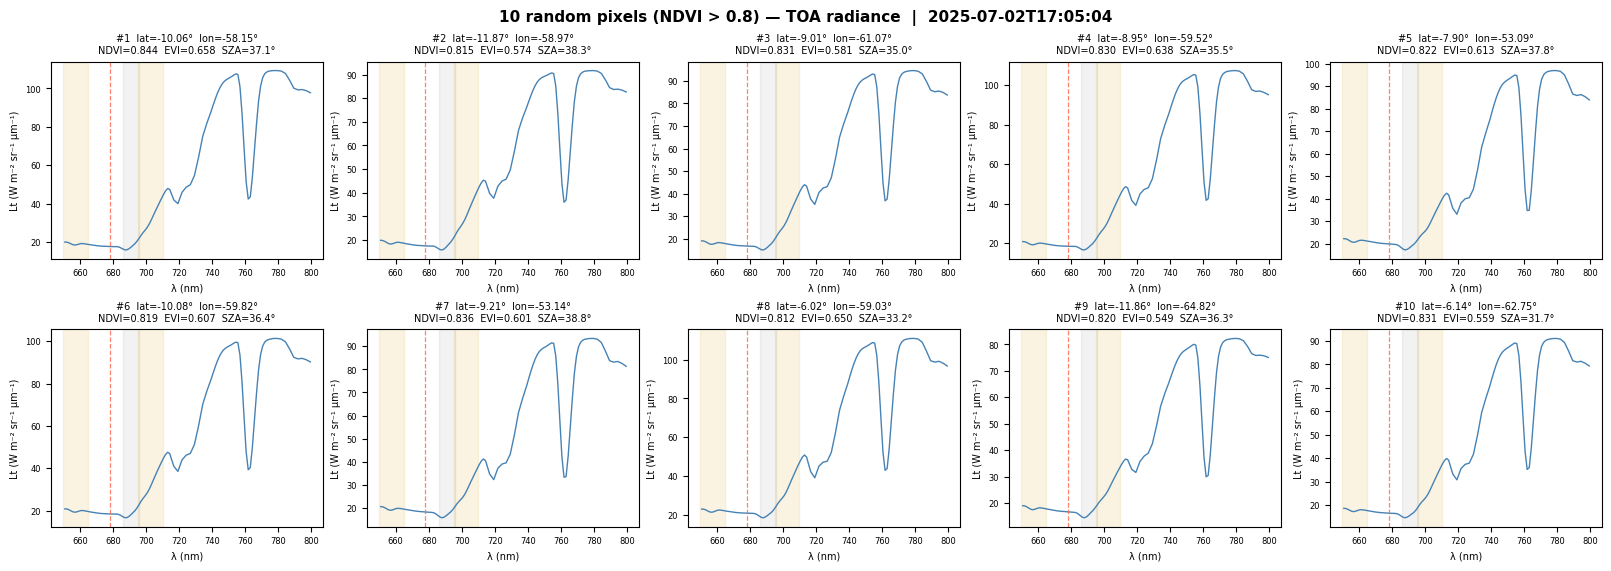

In [24]:
# ── Cell 4: Plot TOA radiance spectra (650–800 nm) for all 10 pixels ─────────
ncols = 5
nrows = (N_PIX + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 2.8),
                          constrained_layout=True)
fig.suptitle(
    f"{N_PIX} random pixels (NDVI > {NDVI_MIN}) — TOA radiance  |  {GRANULE_TS}",
    fontsize=11, fontweight="bold"
)

wl_mask = (chosen[0]["wl"] >= PLOT_WL[0]) & (chosen[0]["wl"] <= PLOT_WL[1])

for k, (ax, p) in enumerate(zip(axes.ravel(), chosen)):
    ax.plot(p["wl"][wl_mask], p["Lt"][wl_mask], lw=1.0, color="steelblue")
    ax.axvline(678, color="tomato", lw=0.9, ls="--", alpha=0.8)
    ax.axvspan(686, 696, alpha=0.10, color="gray")
    ax.axvspan(*BG_LEFT,  alpha=0.13, color="goldenrod")
    ax.axvspan(*BG_RIGHT, alpha=0.13, color="goldenrod")
    ax.set_title(
        f"#{k+1}  lat={p['lat']:.2f}°  lon={p['lon']:.2f}°\n"
        f"NDVI={p['ndvi']:.3f}  EVI={p['evi']:.3f}  SZA={p['sza']:.1f}°",
        fontsize=7
    )
    ax.set_xlabel("λ (nm)", fontsize=7)
    ax.set_ylabel("Lt (W m⁻² sr⁻¹ µm⁻¹)", fontsize=7)
    ax.tick_params(labelsize=6)

for ax in axes.ravel()[N_PIX:]:
    ax.set_visible(False)

plt.show()

  #       lat        lon    NDVI     SZA       Lt_bg       SIF   SIF/Lt_bg
────────────────────────────────────────────────────────────────────────
  1   -10.062    -58.153   0.844    37.1     25.1439    0.5000     0.01989
  2   -11.869    -58.972   0.815    38.3     24.7274    0.5000     0.02022
  3    -9.007    -61.074   0.831    35.0     23.6521    0.5000     0.02114
  4    -8.954    -59.519   0.830    35.5     25.9856    0.5000     0.01924
  5    -7.896    -53.090   0.822    37.8     25.2337    0.5000     0.01981
  6   -10.076    -59.819   0.819    36.4     25.8834    0.5000     0.01932
  7    -9.205    -53.145   0.836    38.8     23.7376    0.5000     0.02106
  8    -6.025    -59.032   0.812    33.2     27.9167    0.5000     0.01791
  9   -11.863    -64.816   0.820    36.3     21.8096    0.5000     0.02293
 10    -6.142    -62.755   0.831    31.7     22.1947    0.5000     0.02253
────────────────────────────────────────────────────────────────────────

Median SIF / Lt_bg: 0.02005


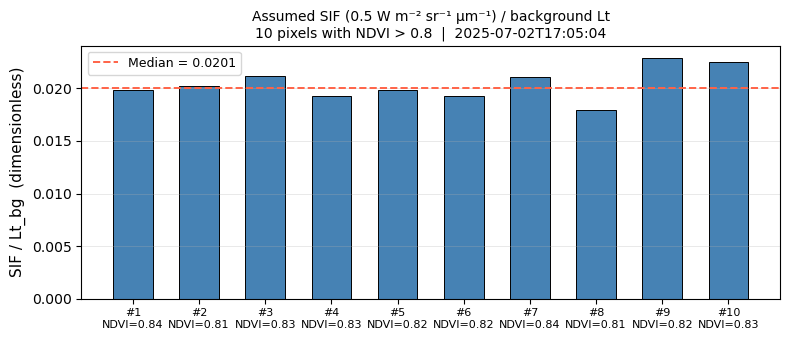

In [25]:
# ── Cell 5: Assumed SIF / background radiance ratio for each pixel ────────────
print(f"{'#':>3}  {'lat':>8}  {'lon':>9}  {'NDVI':>6}  {'SZA':>6}  "
      f"{'Lt_bg':>10}  {'SIF':>8}  {'SIF/Lt_bg':>10}")
print("─" * 72)

ratios = []
for k, p in enumerate(chosen):
    wl, Lt = p["wl"], p["Lt"]
    Lt_bg = (
        Lt[(wl >= BG_LEFT[0])  & (wl <= BG_LEFT[1])].mean() +
        Lt[(wl >= BG_RIGHT[0]) & (wl <= BG_RIGHT[1])].mean()
    ) / 2.0
    ratio = ASSUMED_SIF / Lt_bg
    ratios.append(ratio)
    p["Lt_bg"] = Lt_bg
    p["ratio"] = ratio
    print(f"{k+1:>3}  {p['lat']:>8.3f}  {p['lon']:>9.3f}  {p['ndvi']:>6.3f}  "
          f"{p['sza']:>6.1f}  {Lt_bg:>10.4f}  {ASSUMED_SIF:>8.4f}  {ratio:>10.5f}")

print("─" * 72)
print(f"\nMedian SIF / Lt_bg: {np.median(ratios):.5f}")
print(f"Mean   SIF / Lt_bg: {np.mean(ratios):.5f}")

fig, ax = plt.subplots(figsize=(8, 3.5))
x = np.arange(1, N_PIX + 1)
ax.bar(x, ratios, color="steelblue", edgecolor="k", lw=0.7, width=0.6)
ax.axhline(np.median(ratios), color="tomato", lw=1.4, ls="--",
           label=f"Median = {np.median(ratios):.4f}")
ax.set_xticks(x)
ax.set_xticklabels([f"#{i}\nNDVI={chosen[i-1]['ndvi']:.2f}" for i in x], fontsize=8)
ax.set_ylabel("SIF / Lt_bg  (dimensionless)", fontsize=11)
ax.set_title(
    f"Assumed SIF ({ASSUMED_SIF} W m⁻² sr⁻¹ µm⁻¹) / background Lt\n"
    f"10 pixels with NDVI > {NDVI_MIN}  |  {GRANULE_TS}",
    fontsize=10
)
ax.legend(fontsize=9)
ax.grid(axis="y", lw=0.4, alpha=0.5)
plt.tight_layout()
plt.show()

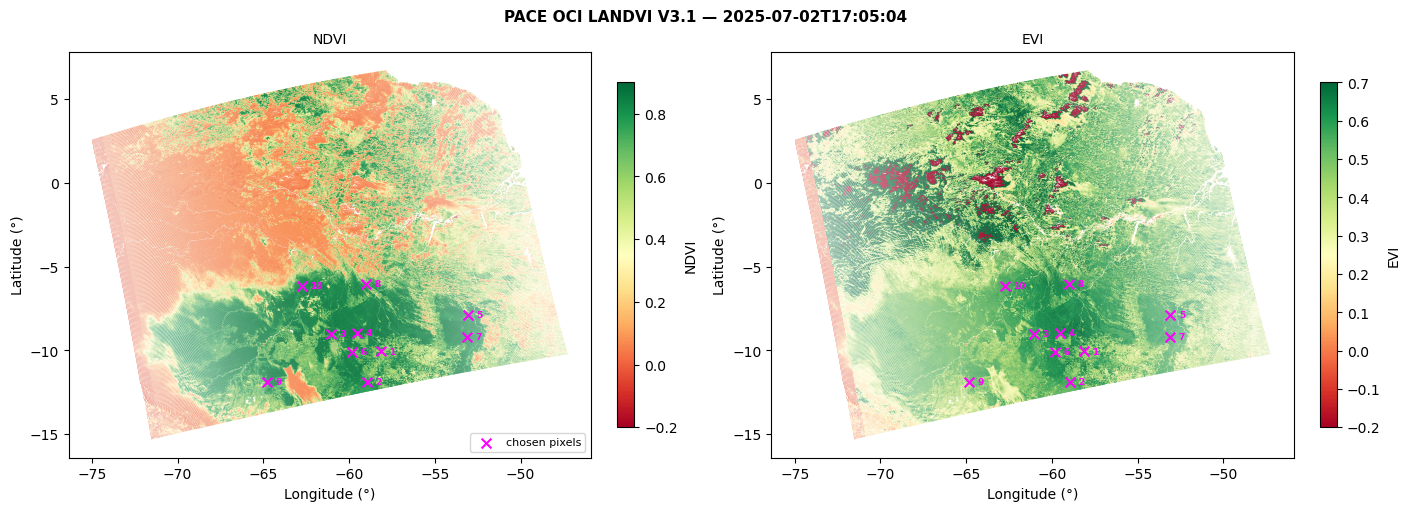

In [28]:
# ── Cell 6: LANDVI full-scene map (NDVI & EVI) ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
fig.suptitle(f"PACE OCI LANDVI V3.1 — {GRANULE_TS}", fontsize=11, fontweight="bold")

for ax, (name, data, vlo, vhi) in zip(axes, [
    ("NDVI", ndvi_full, -0.2, 0.9),
    ("EVI",  evi_full,  -0.2, 0.7),
]):
    mask = np.isfinite(data)
    sc = ax.scatter(
        lon_lv[mask], lat_lv[mask],
        c=data[mask], s=0.05,
        cmap="RdYlGn", vmin=vlo, vmax=vhi,
        linewidths=0, rasterized=True,
    )
    # overlay chosen pixels
    xs = [p["lon"] for p in chosen]
    ys = [p["lat"] for p in chosen]
    ax.scatter(xs, ys, c="magenta", s=50, marker="x",
               linewidths=1.5, zorder=5, label="chosen pixels")
    for k, (x, y) in enumerate(zip(xs, ys)):
        ax.text(x + 0.5, y, str(k + 1), color="magenta",
                fontsize=6.5, va="center", fontweight="bold")
    plt.colorbar(sc, ax=ax, label=name, shrink=0.85)
    ax.set_xlabel("Longitude (°)", fontsize=10)
    ax.set_ylabel("Latitude (°)",  fontsize=10)
    ax.set_title(name, fontsize=10)
    if name == "NDVI":
        ax.legend(fontsize=8, loc="lower right")

plt.show()